In [135]:
import pandas as pd
import numpy as np

%load_ext autoreload
%autoreload 2
import tme5

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Cultures associées et Maraîchage diversifié

L'agriculture est dominée par un modèle où de grandes exploitations cultivent en monocultures. Pourtant, de plus en plus de données montrent que ce type d'agriculture n'est pas soutenable. En focalisant sur le maraîchage, ce sujet propose d'explorer la viabilité des fermes qui cultivent de multiples variétés de légumes. 

Dans un premier temps, on étudiera les données qui indiquent si la pratique qui consiste à mélanger des cultures sur une même parcelle permet d'obtenir de bons rendements. Ensuite, il s'agit de déterminer si les fermes de maraîchage diversifiés sont viable en termes de revenus et de charge de travail. Enfin, on s'intéressera à la façon de réaliser ces associations dans des simulations spatialisées de la ferme.

# TME5: Analyse de données de cultures associées

On considère des associations de 2 cultures ($Crop_1$ et $Crop_2$) et on s'intéresse aux rendements de différentes couples de cultures associées ($I_i$, dans la base : `crop_{i}_yield_intercroped`) comparés à ceux des cultures seules ($S_i$, dans la base : `crop_{i}_yield_sole`). 

On a a disposition 2 datasets qui rassemblent les rendememts pour les cultures isolées et pour les cultures mélangées Ces données sont issues des publications suivantes:
* Li, C., Stomph, T. J., Makowski, D., Li, H., Zhang, C., Zhang, F., & van der Werf, W. (2023). The productive performance of intercropping. Proceedings of the National Academy of Sciences, 120(2), e2201886120
* Paut, R., Garreau, L., Ollivier, G., Sabatier, R., & Tchamitchian, M. (2024). A global dataset of experimental intercropping and agroforestry studies in horticulture. Scientific Data, 11(1), 5.

## 1. Extraction et prétraitement des données

La lecture des 2 bases est compliquée par des colonnes non nécessaires et des noms différents. Le code des 2 cellules suivantes fournissent 2 dataframe avec les mêmes noms de colonnes.

In [136]:
d1=pd.read_csv("res/dataset_PNAS_2023.csv",index_col=0)
d1[['Crop_1_Common_Name', 'Crop_2_Common_Name']] = d1['Crop_names'].str.split('/', n=1, expand=True)
d1=d1.drop(columns=["Crop_names"])
d1.iloc[0] # première ligne du dataframe 1

Crop_1_yield_sole              9.14
Crop_2_yield_sole              5.77
Crop_1_yield_intercropped      5.21
Crop_2_yield_intercropped      2.29
LER_tot                        0.97
Crop_1_Common_Name            Maize
Crop_2_Common_Name           millet
Name: 0, dtype: object

In [137]:
d2=pd.read_csv("res/dataset_natcom_2024.csv")[['Crop_1_yield_sole',
                                               'Crop_2_yield_sole',
                                               'Crop_1_yield_intercropped',
                                               'Crop_2_yield_intercropped',
                                               'LER_tot','Crop_1_Common_Name',
                                               'Crop_2_Common_Name']]
d2.iloc[0]  # première ligne du dataframe 2

Crop_1_yield_sole                 2.46
Crop_2_yield_sole                  2.2
Crop_1_yield_intercropped          2.0
Crop_2_yield_intercropped         0.91
LER_tot                           1.22
Crop_1_Common_Name               Maize
Crop_2_Common_Name           Groundnut
Name: 0, dtype: object

Ces données sont parfois incomplètes, certaines entrées ne sont pas des nombres valides ou ont des valeurs nulles pour les $S_i$.

In [138]:
print("d2.iloc[7]\n------------")
print(d2.iloc[7])
print()
print("d2.iloc[1416]\n------------")
print(d2.iloc[1416])

d2.iloc[7]
------------
Crop_1_yield_sole                  5.7
Crop_2_yield_sole                  NaN
Crop_1_yield_intercropped         8.31
Crop_2_yield_intercropped          NaN
LER_tot                            NaN
Crop_1_Common_Name           Fava bean
Crop_2_Common_Name           Fenugreek
Name: 7, dtype: object

d2.iloc[1416]
------------
Crop_1_yield_sole               0.0
Crop_2_yield_sole              3.42
Crop_1_yield_intercropped       0.0
Crop_2_yield_intercropped      3.29
LER_tot                        0.77
Crop_1_Common_Name            Apple
Crop_2_Common_Name           Peanut
Name: 1416, dtype: object


Écrire une fonction qui, pour une dataframe et une liste de variables/colonnes, renvoie les indices des entrées où ces colonnes sont des nombres valides. 

**Note** 
`x>0` est faux pour `x==NaN` ou `x==0`).

In [139]:
fields_to_test = ['Crop_1_yield_sole','Crop_2_yield_sole','LER_tot','Crop_1_yield_intercropped','Crop_2_yield_intercropped']
idxs1 = tme5.get_valid_indices_all_vars(d1,fields_to_test)

print("%s/%s entrées sont valides dans d1"%(len(idxs1), len(d1)))
print("Trois premiers indices invalides dans d1 : %s"%sorted(list(set(range(1,935))-set(idxs1)))[:3])

927/934 entrées sont valides dans d1
Trois premiers indices invalides dans d1 : [536, 538, 546]


In [140]:
idxs2 = tme5.get_valid_indices_all_vars(d2,fields_to_test)

print("%s/%s entrées sont valides dans d1"%(len(idxs2), len(d2)))
print("Dix premiers indices invalides dans d1 : %s"%sorted(set(range(1,1545))-set(idxs2))[:10])

636/1544 entrées sont valides dans d1
Dix premiers indices invalides dans d1 : [6, 7, 8, 9, 56, 57, 58, 59, 60, 61]


In [141]:
# nous nous limitons donc aux données valides
d1v=d1.iloc[idxs1]
d2v=d2.iloc[idxs2]

In [142]:
d1v['Crop_2_yield_intercropped'].isna().any

<bound method Series.any of 0      False
1      False
2      False
3      False
4      False
       ...  
929    False
930    False
931    False
932    False
933    False
Name: Crop_2_yield_intercropped, Length: 927, dtype: bool>

## 2. Analyse descriptive des LERs

Pour une culture, on définit le ratio de terrain équivalent (**LER-Land equivalent ratio**) comme 

$$\forall i \in \{1,2\}, LER_i=\frac{I_i}{S_i}$$ 

Le LER total pour une association est alors 

$$LER_{tot} = \sum_{i \in \{1,2\}} LER_i$$ 

Dans les 2 bases, il existe un champ $LER_{tot}$ qui a été mesuré autrement que par ce calcul. On voudrai analyser l'adéquation entre observation et calcul.



### 2.1. Calculer (dans un `numpy.array`) les $LER_{tot}$ pour les deux datasets en utilisants les entrées valides..

In [143]:
np.sum(d1v['Crop_1_yield_intercropped'])

2747.91

In [144]:
print("5 premières valeurs dans d1v : %s"%d1v['LER_tot'].to_numpy()[:5])
LER_calc_1 = tme5.compute_LER(d1v) # LER_Calc_1 est un vecteur numpy des valeurs calculés dans d1v
print("5 premières valeurs calculées dans d1v: %s"%LER_calc_1[:5])
print()
print("5 premières valeurs dans d2v : %s"%d2v['LER_tot'].to_numpy()[:5])
LER_calc_2 = tme5.compute_LER(d2v) # LER_Calc_2 est un vecteur numpy des valeurs calculés dans d2v
print("5 premières valeurs calculées dans d2c: %s"%LER_calc_2[:5])


5 premières valeurs dans d1v : [0.97 1.06 1.2  1.12 1.62]
5 premières valeurs calculées dans d1v: [0.9669023  1.05724736 1.20604168 1.11503878 1.6160205 ]

5 premières valeurs dans d2v : [1.22 1.26 1.12 1.44 0.85]
5 premières valeurs calculées dans d2c: [1.22664449 1.24922904 1.11640798 1.40234407 3.21768707]


###  2.2. Tracer des graphe de comparaison entre $LER_{tot}$ calculés et $LER_{tot}$ observés.

Tracer 
  - les points $(LER_{tot},LER_{calc})$ qui devraient être sur la droite $y=x$,
  - la liste triée des erreurs $LER_{tot}-LER_{calc}$
  - la distribution de ces erreurs. Pour tracer l'histograme : utiliser la fonction `hist` de `pyplot` avec 30 bins. Pour avoir le même rendu : `color="skyblue", edgecolor="black"`.

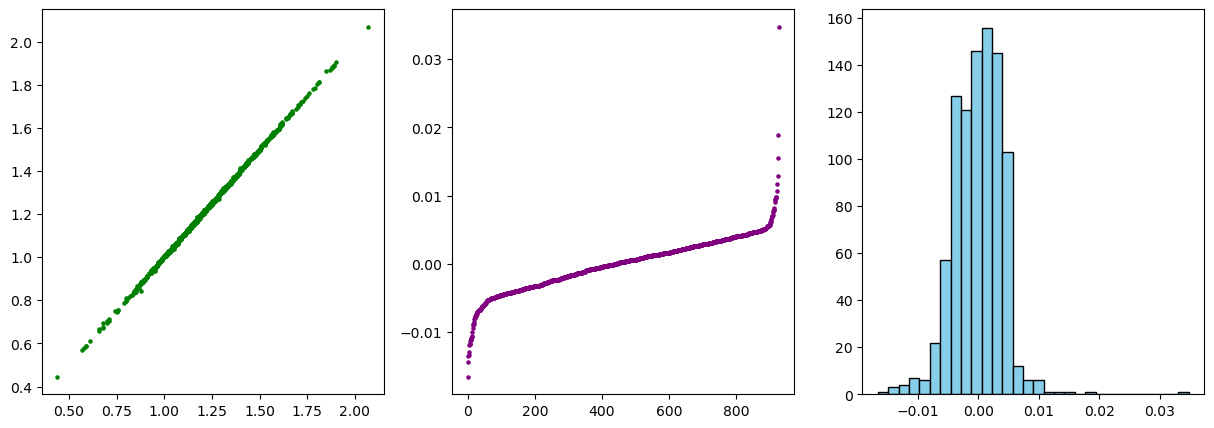

In [145]:
# plot_compare_LERs compare 2 vecteurs numpy (de même taille)
tme5.plot_compare_LERs(d1v['LER_tot'].to_numpy(),LER_calc_1)

In [146]:
d2v['LER_tot'].isna().any

<bound method Series.any of 0       False
1       False
2       False
3       False
4       False
        ...  
1539    False
1540    False
1541    False
1542    False
1543    False
Name: LER_tot, Length: 636, dtype: bool>

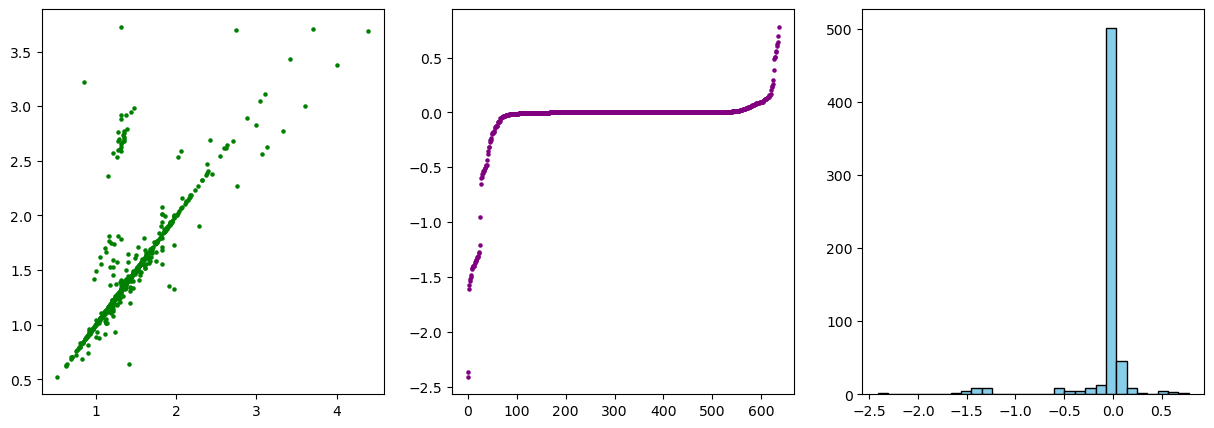

In [147]:

tme5.plot_compare_LERs(d2v['LER_tot'].to_numpy(),LER_calc_2)

Il y a donc une différence notable entre le calcul et l'observation de LER_tot et un comportement différent par base. Nous allons nous attacher à décrire la donnée `LER_tot` des bases.

### 2.3. Calculer la moyenne et la variance des LERs_tot dans les 2 bases

Proposer une fonction `compute_mean_std(df,varname)` qui peut calculer la moyenne et l'écart-type de toute variable/colonne du dataframe.

In [11]:
tme5.compute_mean_std(d1v,"Crop_1_yield_sole")

(4.366957928802589, 2.923427526381599)

Calculer la moyenne $µ_i$ et l'écart-type $σ_i$ de `LER_tot` dans le 2 bases ($i \in [1,2]$)

In [12]:
# calcul moyenne et variance 
m1, s1= tme5.compute_mean_std(d1v,'LER_tot')
print("Dataset 1 : Mean=%f5, std=%f5"%(m1, s1))

m2, s2= tme5.compute_mean_std(d2v,'LER_tot')
print("Dataset 2 : Mean=%f5, std=%f5"%(m2, s2))

Dataset 1 : Mean=1.2170125, std=0.2249055
Dataset 2 : Mean=1.4318185, std=0.4492185


## 3. Analyse inférentielle : distribution de la moyenne

Ces moyennes sont obtenues sur un échantillon de la taille des bases de `d1v` et `d2v`. Quel crédit peut-on leur donner en tant qu'estimateurs des **vraies** moyennes de la variable `LER_tot` dans ces 2 expériences? 

Nous allons donc analyser le comportement de cet estimateur sur de nombreuses sous-bases de `d1v` (on aurait pu utiliser `d2v`). 

Dans cette partie, nous considérons donc que `d1v` *est la population* et que nous essayons d'estimer `m1` à partir d'échantillons issus de `d1v`. Donc des **sous-échantillons**.

### 3.1. Générer une distribution de moyennes pour des sous-bases de taille $N$

La fonction `means_subsample(df,varname,size,N)` génére `size` sous-bases aléatoires de taille `N` de la base `df` (sans remise), pour la variable/colonne `varname`et calcule la moyenne de ces sous-échantillons. 

In [13]:
print("Résultat non aléatoire (moyenne sur toute la base, 4 fois)         : %s"%str(tme5.means_subsample(d1v,"LER_tot",4,len(d1v))))
print("Résultat aléatoire (moyenne sur une sous-base de taille 15, 4 fois): %s"%str(tme5.means_subsample(d1v,"LER_tot",4,15)))

Résultat non aléatoire (moyenne sur toute la base, 4 fois)         : [1.2170118662351672, 1.2170118662351672, 1.2170118662351672, 1.2170118662351672]
Résultat aléatoire (moyenne sur une sous-base de taille 15, 4 fois): [1.252, 1.2213333333333334, 1.182, 1.2019999999999997]


### 3.2. Afficher la distribution des moyennes des sous-bases

- Écrire une fonction `plot_means_subsample(df,varname,size,N)`qui affiche la distribution des moyennes des `size` sous-bases de taille `N`. 
- **Afficher dans le titre** de la figure, `size` , `N`et la valeur de la moyenne et de l'écart type de cette distribution.

Utiliser $N/10$ comme nombre de bins afin d'avoir une granularité assez fine. 

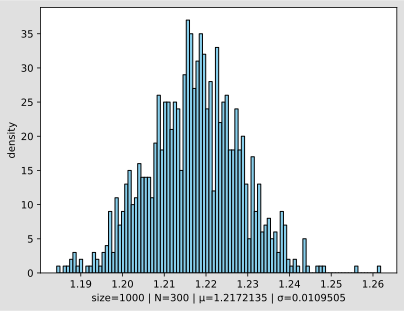

In [14]:
tme5.plot_means_subsample(d1v,"LER_tot",1000,300)

Pour voir l'influence de `size` et `N`, on aimerait afficher cette figure pour une série de valeurs de ces 2 paramètres. Écrire une fonction `grid_means_subsample(d1v,"LER_tot",liste_size,liste_N)` qui fait ce travail :

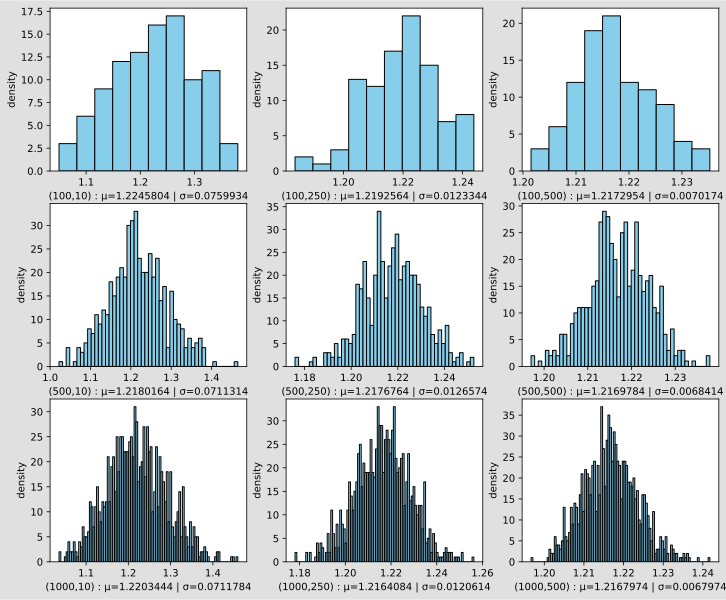

In [15]:
tme5.grid_means_subsample(d1v,"LER_tot",[100,500,1000],[10,250,500])

On observe que `size` et `N` ont assez peu d'impact sur les valeurs moyennes obtenues (qui sont proches de la valeur moyenne de tous l'échantillon :  `m1`). 

Par contre, la taille `N` semble avoir un impact important sur l'écart-type. On se propose donc d'étudier sa variabilité : $\sigma_N$.

### 3.3. Tracer l'écart-type obtenu pour `size=100`, en fonction de `N`.

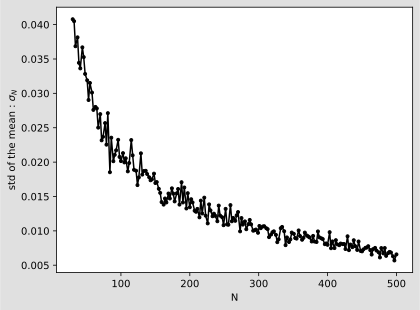

In [16]:
tme5.plot_std_subsample(d1v,"LER_tot",min_n=30,max_n=500,nbr_n=200) 
# on affiche 100 pts pour N variant de 30 à 500, avec size=100

Donc plus `n` est grand plus l'estimation de la moyenne est bonne puisque l'écart-type diminue.
Comment diminue-t-il ?

Tracer sur la même figure la fonction $\frac{s}{\sqrt{n}}$ où $s$ est fourni en argument. Nous utiliserons `s1` comme valeur pour $s$.

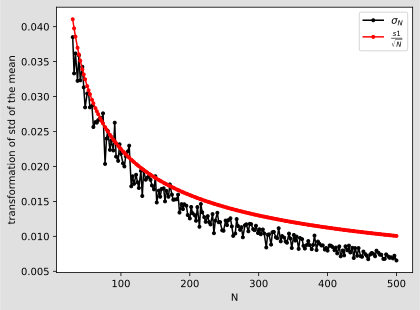

In [17]:
tme5.plot_extended_std_subsample(d1v,"LER_tot",s1,min_n=30,max_n=500,nbr_n=200) 
# on affiche 100 pts pour N variant de 30 à 500, avec size=100

Le comportement théorique semble être à peu près le "bon". Toutefois, nous observons (quand $N$ devient grand) un écart qui semble croissant entre la théorie et les valeurs expérimentales. 

Ce qui est choquant puisque, normalement, on s'attend à ce que ce soit de plus en plus exact avec la taille de l'échantillon (comportement asymptotique)... Êtes-vous capable de trouver pourquoi (c'est un peu duraille) ?

On peut corriger ce problème :

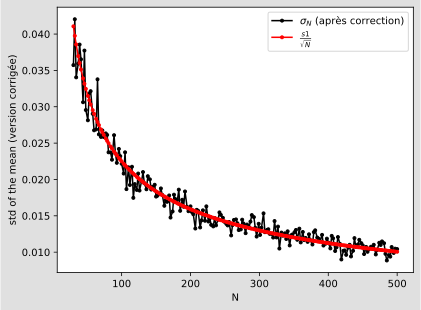

In [18]:
tme5.plot_CORRIGE_std_subsample(d1v,"LER_tot",s1,min_n=30,max_n=500,nbr_n=200) 
# on affiche 100 pts pour N variant de 30 à 500, avec size=100

On peut vérifier que les valeur obtenus sont bien des estimations de $s1$ en traçant la transformation $f(N)=\sqrt{N \cdot σ_N^2}$

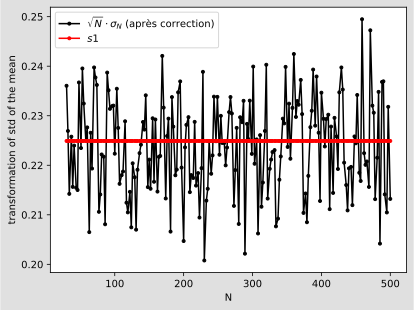

In [19]:
tme5.plot_CORRIGE_TRANSFORMATION__std_subsample(d1v,"LER_tot",s1,min_n=30,max_n=500,nbr_n=200) 
# on affiche 100 pts pour N variant de 30 à 500, avec size=100

Alors que la version non corrigée ne se comporte pas très bien :

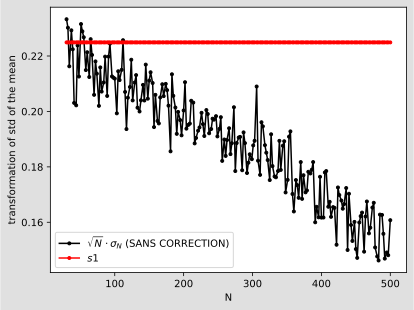

In [20]:
tme5.plot_TRANSFORMATION_SANS_CORRECTION__std_subsample(d1v,"LER_tot",s1,min_n=30,max_n=500,nbr_n=200) 
# on affiche 100 pts pour N variant de 30 à 500, avec size=100